# Prédiction des retards de vols domestiques US

Ce notebook rassemble le projet en quatre étapes reproductibles. La cible métier est maintenant simple : **un vol est en retard lorsque `arr_delay > 0`**. Les causes de retard et l'estimation des minutes ne font plus partie du machine learning.

Le code et les noms techniques restent en anglais ; les explications et les graphiques sont en français.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

SPARK_SAMPLE_SIZE = 10_000
SPARK_SAMPLE_SEED = 42
ML_SAMPLE_FRACTION = 0.1
RETRAIN_MODEL = False

RAW_SAMPLE_PATH = PROJECT_ROOT / "data/flight_data_2024_sample.csv"
FULL_DATA_PATH = PROJECT_ROOT / "data/flight_data_2024.csv"
SPARK_OUTPUT = PROJECT_ROOT / "data/processed/spark/flights_10000"
ANALYSIS_OUTPUT = PROJECT_ROOT / "data/analysis/spark"
MODEL_DIRECTORY = PROJECT_ROOT / "models/official"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

display(Markdown(f"**Racine du projet :** `{PROJECT_ROOT}`"))
display(Markdown(f"**CSV complet disponible :** {'oui' if FULL_DATA_PATH.exists() else 'non'}"))

**Racine du projet :** `/Users/noam/Documents/ESGI/5AL/TRAITEMENTS-DISTRIBUES`

**CSV complet disponible :** oui

# Étape 1 — Parsing avec PySpark

Spark lit les 10 000 lignes avec un schéma textuel explicite, convertit les types, contrôle les règles de qualité puis écrit les lignes valides en Parquet. Les cinq colonnes de causes postérieures au vol sont exclues du dataset propre.

In [2]:
from flight_delays.parsing import (
    create_spark_session,
    parse_and_validate,
    read_flights_csv,
    sample_rows,
    split_rows,
    write_results,
)

spark = create_spark_session(
    application_name="Notebook des retards de vols",
    master="local[2]",
)
spark.sparkContext.setLogLevel("WARN")

raw_spark = read_flights_csv(spark, str(RAW_SAMPLE_PATH))
sampled_spark = sample_rows(raw_spark, SPARK_SAMPLE_SIZE, SPARK_SAMPLE_SEED)
validated_spark = parse_and_validate(sampled_spark).cache()
valid_spark, rejected_spark = split_rows(validated_spark)

valid_count = valid_spark.count()
rejected_count = rejected_spark.count()
write_results(validated_spark, str(SPARK_OUTPUT), mode="overwrite")

print(f"Lignes valides : {valid_count:,}")
print(f"Lignes en quarantaine : {rejected_count:,}")

26/07/17 18:43:25 WARN Utils: Your hostname, MacBook-Pro-de-Noam.local resolves to a loopback address: 127.0.0.1; using 25.40.244.151 instead (on interface en10)
26/07/17 18:43:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/17 18:43:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/07/17 18:43:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


26/07/17 18:43:31 WARN CacheManager: Asked to cache already cached data.


Lignes valides : 10,000
Lignes en quarantaine : 0


In [3]:
removed_cause_columns = {
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay",
}
raw_preview = pd.read_csv(RAW_SAMPLE_PATH, nrows=8).drop(
    columns=list(removed_cause_columns),
    errors="ignore",
)
clean_spark = spark.read.parquet(str(SPARK_OUTPUT / "flights"))
clean_preview = clean_spark.limit(8).toPandas()

display(Markdown("### Aperçu du CSV brut sans les causes exclues"), raw_preview)
display(Markdown("### Aperçu du Parquet propre"), clean_preview)

print("Causes absentes du Parquet :", removed_cause_columns.isdisjoint(clean_spark.columns))

### Aperçu du CSV brut sans les causes exclues

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,1018,1015.0,-3.0,21.0,1036.0,1135.0,4.0,1149,1139.0,-10.0,0,NaN,0,151.0,144.0,119.0,835.0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,1637,1633.0,-4.0,14.0,1647.0,1900.0,6.0,1923,1906.0,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,1000,952.0,-8.0,13.0,1005.0,1034.0,8.0,1059,1042.0,-17.0,0,NaN,0,59.0,50.0,29.0,106.0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,1330,1334.0,4.0,8.0,1342.0,1425.0,6.0,1430,1431.0,1.0,0,NaN,0,180.0,177.0,163.0,1099.0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,1340,1333.0,-7.0,16.0,1349.0,1505.0,4.0,1510,1509.0,-1.0,0,NaN,0,90.0,96.0,76.0,399.0
5,2024,4,15,1,2024-04-15,WN,2358.0,SAN,"San Diego, CA",California,PHX,"Phoenix, AZ",Arizona,715,708.0,-7.0,13.0,721.0,812.0,4.0,830,816.0,-14.0,0,NaN,0,75.0,68.0,51.0,304.0
6,2024,11,27,3,2024-11-27,G4,163.0,MLB,"Melbourne, FL",Florida,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,933,924.0,-9.0,12.0,936.0,1153.0,5.0,1202,1158.0,-4.0,0,NaN,0,149.0,154.0,137.0,914.0
7,2024,8,31,6,2024-08-31,AS,1269.0,BNA,"Nashville, TN",Tennessee,PDX,"Portland, OR",Oregon,1855,1850.0,-5.0,21.0,1911.0,2125.0,3.0,2155,2128.0,-27.0,0,NaN,0,300.0,278.0,254.0,1973.0


### Aperçu du Parquet propre

,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,scheduled_departure_minutes,scheduled_arrival_minutes,year,month
0,9,3,2024-10-09,YX,5780,BOS,"Boston, MA",Massachusetts,CVG,"Cincinnati, OH",Kentucky,845,843,-2.0,19.0,902,1106,4.0,1114,1110,-4.0,0,None,0,149.0,147.0,124.0,752.0,525,674,2024,10
1,25,5,2024-10-25,AA,298,MIA,"Miami, FL",Florida,IND,"Indianapolis, IN",Indiana,1535,1532,-3.0,12.0,1544,1804,6.0,1824,1810,-14.0,0,None,0,169.0,158.0,140.0,1020.0,935,1104,2024,10
2,25,5,2024-10-25,UA,2046,EWR,"Newark, NJ",New Jersey,MSP,"Minneapolis, MN",Minnesota,1410,1405,-5.0,18.0,1423,1558,10.0,1603,1608,5.0,0,None,0,173.0,183.0,155.0,1008.0,850,963,2024,10
3,20,7,2024-10-20,DL,1295,ATL,"Atlanta, GA",Georgia,FLL,"Fort Lauderdale, FL",Florida,1645,1645,0.0,14.0,1659,1819,13.0,1834,1832,-2.0,0,None,0,109.0,107.0,80.0,581.0,1005,1114,2024,10
4,6,7,2024-10-06,NK,3170,OAK,"Oakland, CA",California,LAS,"Las Vegas, NV",Nevada,1650,1642,-8.0,11.0,1653,1804,8.0,1820,1812,-8.0,0,None,0,90.0,90.0,71.0,407.0,1010,1100,2024,10
5,18,5,2024-10-18,WN,1668,ELP,"El Paso, TX",Texas,HOU,"Houston, TX",Texas,700,657,-3.0,15.0,712,941,7.0,945,948,3.0,0,None,0,105.0,111.0,89.0,677.0,420,585,2024,10
6,21,1,2024-10-21,YX,3443,EWR,"Newark, NJ",New Jersey,IND,"Indianapolis, IN",Indiana,1520,1513,-7.0,17.0,1530,1658,7.0,1734,1705,-29.0,0,None,0,134.0,112.0,88.0,645.0,920,1054,2024,10
7,16,3,2024-10-16,MQ,3928,DFW,"Dallas/Fort Worth, TX",Texas,COS,"Colorado Springs, CO",Colorado,1313,1310,-3.0,14.0,1324,1355,7.0,1410,1402,-8.0,0,None,0,117.0,112.0,91.0,592.0,793,850,2024,10


Causes absentes du Parquet : True


Le CSV brut conserve son format d'origine, mais les causes officielles ne sont plus propagées dans le Parquet. Elles sont constatées après le vol et ne répondent pas à l'objectif binaire retenu.

# Étape 2 — Analyse avec PySpark

L'analyse utilise désormais la même définition que le modèle : tout retard d'arrivée strictement positif. Elle décrit les statuts, les variations mensuelles, les compagnies, les aéroports et les corrélations, sans analyser les causes.

In [4]:
from flight_delays.analysis import (
    build_group_metrics,
    build_missing_values,
    build_status_distribution,
    write_analysis,
)

overview_spark, correlations_spark, correlation_row_count = write_analysis(
    clean_spark,
    str(ANALYSIS_OUTPUT),
    mode="overwrite",
)
overview = overview_spark.first().asDict()
status_metrics = build_status_distribution(clean_spark).toPandas()
monthly_metrics = build_group_metrics(clean_spark, "month").orderBy("month").toPandas()
carrier_metrics = build_group_metrics(clean_spark, "op_unique_carrier").toPandas()
origin_metrics = build_group_metrics(clean_spark, "origin").toPandas()
missing_values = build_missing_values(clean_spark).toPandas()
arrival_correlations = correlations_spark.toPandas()

overview_table = pd.DataFrame(
    {
        "Indicateur": [
            "Vols analysés",
            "Vols achevés",
            "Vols arrivés en retard",
            "Taux de retard",
            "Vols annulés",
            "Vols déroutés",
            "Retard moyen",
            "Retard médian",
        ],
        "Valeur": [
            f"{overview['flight_count']:,}",
            f"{overview['completed_flight_count']:,}",
            f"{overview['delayed_flight_count']:,}",
            f"{overview['delayed_flight_percentage']:.1f} %",
            f"{overview['cancelled_flight_count']:,}",
            f"{overview['diverted_flight_count']:,}",
            f"{overview['average_arrival_delay_minutes']:.1f} min",
            f"{overview['median_arrival_delay_minutes']:.0f} min",
        ],
    }
)
display(overview_table)
print(f"Vols utilisés pour les corrélations : {correlation_row_count:,}")

26/07/17 18:43:39 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/07/17 18:43:39 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


,Indicateur,Valeur
0,Vols analysés,"10,000"
1,Vols achevés,"9,836"
2,Vols arrivés en retard,"3,578"
3,Taux de retard,36.4 %
4,Vols annulés,122
5,Vols déroutés,42
6,Retard moyen,7.5 min
7,Retard médian,-6 min


Vols utilisés pour les corrélations : 9,836


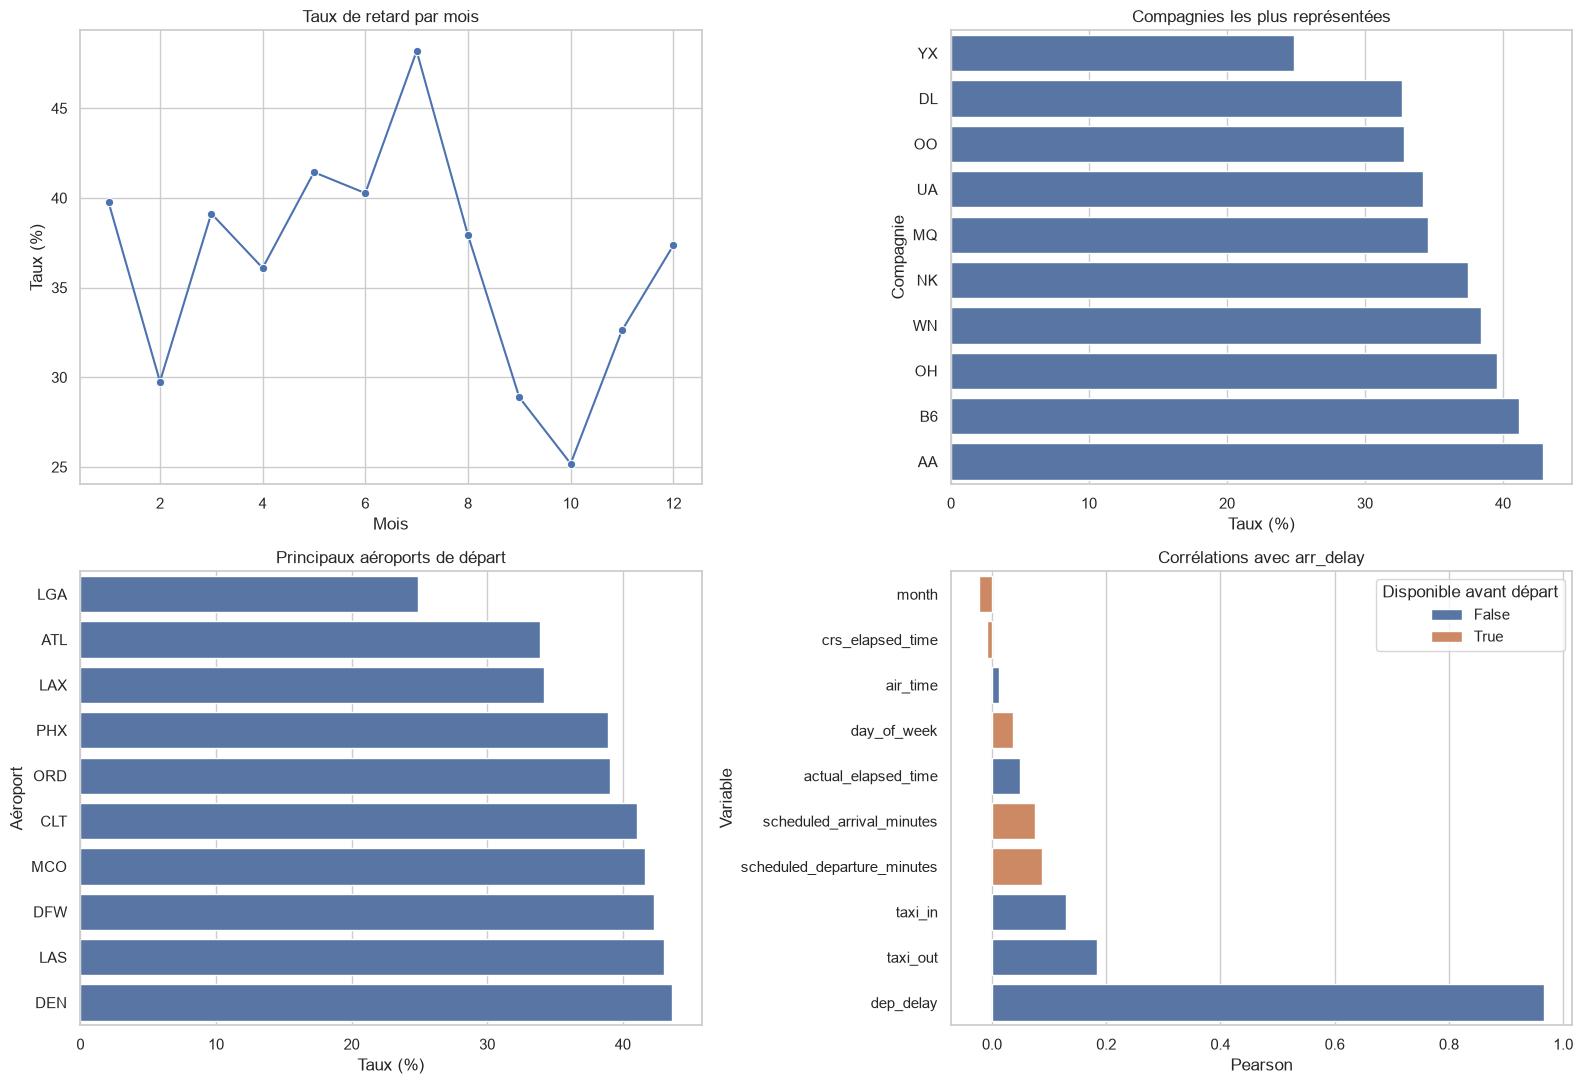

### Valeurs manquantes les plus fréquentes

,column,missing_count,missing_percentage
0,cancellation_code,9878,98.78
1,actual_elapsed_time,164,1.64
2,air_time,164,1.64
3,arr_delay,164,1.64
4,arr_time,127,1.27
5,taxi_in,127,1.27
6,wheels_on,127,1.27
7,taxi_out,120,1.20
8,wheels_off,120,1.20
9,dep_delay,116,1.16


### Corrélations avec le retard d'arrivée

,variable,correlation,absolute_correlation,available_before_departure
0,dep_delay,0.966336,0.966336,False
1,taxi_out,0.184382,0.184382,False
2,taxi_in,0.130079,0.130079,False
3,scheduled_departure_minutes,0.087305,0.087305,True
4,scheduled_arrival_minutes,0.075227,0.075227,True
5,actual_elapsed_time,0.048491,0.048491,False
6,day_of_week,0.036520,0.036520,True
7,month,-0.022361,0.022361,True
8,air_time,0.011417,0.011417,False
9,crs_elapsed_time,-0.008349,0.008349,True


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.lineplot(
    data=monthly_metrics,
    x="month",
    y="delayed_flight_percentage",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set(title="Taux de retard par mois", xlabel="Mois", ylabel="Taux (%)")

top_carriers = carrier_metrics.head(10).sort_values("delayed_flight_percentage")
sns.barplot(
    data=top_carriers,
    y="op_unique_carrier",
    x="delayed_flight_percentage",
    ax=axes[0, 1],
)
axes[0, 1].set(title="Compagnies les plus représentées", xlabel="Taux (%)", ylabel="Compagnie")

top_origins = origin_metrics.head(10).sort_values("delayed_flight_percentage")
sns.barplot(
    data=top_origins,
    y="origin",
    x="delayed_flight_percentage",
    ax=axes[1, 0],
)
axes[1, 0].set(title="Principaux aéroports de départ", xlabel="Taux (%)", ylabel="Aéroport")

correlation_plot = arrival_correlations.dropna().head(10).sort_values("correlation")
sns.barplot(
    data=correlation_plot,
    y="variable",
    x="correlation",
    hue="available_before_departure",
    ax=axes[1, 1],
)
axes[1, 1].set(title="Corrélations avec arr_delay", xlabel="Pearson", ylabel="Variable")
axes[1, 1].legend(title="Disponible avant départ")

plt.tight_layout()
plt.show()

display(Markdown("### Valeurs manquantes les plus fréquentes"), missing_values.head(12))
display(Markdown("### Corrélations avec le retard d'arrivée"), arrival_correlations)

La corrélation de `dep_delay` avec `arr_delay` est très forte, mais `dep_delay` n'est connu qu'après le départ. Les variables réellement disponibles à l'avance ont des corrélations linéaires faibles ; le modèle doit donc exploiter leurs interactions et les historiques récents.

In [6]:
clean_spark.unpersist()
spark.stop()
print("Session Spark arrêtée.")

Session Spark arrêtée.


# Étape 3 — Machine learning avec Python

Le pipeline Python parcourt le CSV complet pour construire le planning et les historiques, puis entraîne un unique `CatBoostClassifier` sur un échantillon déterministe de 10 %. La cible `is_delayed` vaut 1 lorsque `arr_delay > 0`.

Le contrat métier demande au moins **50 % de précision**, **20 % de rappel** et une couverture comprise entre **5 et 20 %**. Les bornes basses de confiance à 95 % et la stabilité mensuelle sont également contrôlées.

In [7]:
from flight_delays.ml_data import load_ml_data
from flight_delays.prediction import (
    CURRENT_ARTIFACT_VERSION,
    load_model_bundle,
    predict_flight,
)
from flight_delays.training import save_training_outputs, train_models

MODEL_PATH = MODEL_DIRECTORY / "flight_delay_models.joblib"
METRICS_PATH = MODEL_DIRECTORY / "training_metrics.json"
IMPORTANCE_PATH = MODEL_DIRECTORY / "feature_importance.csv"

artifact_is_compatible = False
if MODEL_PATH.exists() and METRICS_PATH.exists() and IMPORTANCE_PATH.exists():
    try:
        bundle = load_model_bundle(str(MODEL_PATH))
        artifact_is_compatible = True
    except ValueError as error:
        print(error)

if RETRAIN_MODEL or not artifact_is_compatible:
    ml_input = FULL_DATA_PATH if FULL_DATA_PATH.exists() else RAW_SAMPLE_PATH
    sample_fraction = ML_SAMPLE_FRACTION if FULL_DATA_PATH.exists() else 1.0
    print(f"Préparation ML depuis {ml_input.name} avec fraction {sample_fraction:.0%}…")
    ml_data = load_ml_data(str(ml_input), sample_fraction=sample_fraction, seed=42)
    bundle, training_metrics, feature_importance = train_models(ml_data, seed=42)
    save_training_outputs(
        bundle,
        training_metrics,
        feature_importance,
        str(MODEL_PATH),
        str(METRICS_PATH),
        str(IMPORTANCE_PATH),
    )
else:
    training_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
    feature_importance = pd.read_csv(IMPORTANCE_PATH)
    print(f"Artefact v{CURRENT_ARTIFACT_VERSION} rechargé sans réentraînement.")

print("Définition de la cible :", bundle["target_definition"])
print("Nombre de modèles dans l'artefact : 1 classifieur")

Artefact v6 rechargé sans réentraînement.
Définition de la cible : {'source': 'arr_delay', 'operator': '>', 'threshold_minutes': 0, 'label': 'is_delayed'}
Nombre de modèles dans l'artefact : 1 classifieur


In [8]:
split_labels = {
    "train": "Entraînement (janvier-juillet)",
    "tuning": "Réglage (août)",
    "validation": "Validation du seuil (septembre-octobre)",
    "test": "Test (novembre-décembre)",
}
split_table = pd.DataFrame(
    [
        {
            "Jeu": split_labels[name],
            "Vols": values["row_count"],
            "Vols retardés": values["delayed_count"],
            "Taux de retard (%)": values["delayed_percentage"],
        }
        for name, values in training_metrics["data"].items()
        if name in split_labels
    ]
)
display(split_table.style.format({"Taux de retard (%)": "{:.2f}"}))

,Jeu,Vols,Vols retardés,Taux de retard (%)
0,Entraînement (janvier-juillet),401778,157369,39.17
1,Réglage (août),60378,23189,38.41
2,Validation du seuil (septembre-octobre),118740,34063,28.69
3,Test (novembre-décembre),115700,37896,32.75


In [9]:
classification = training_metrics["delay_classification"]
business_gate = classification["business_gate"]
validation_metrics = classification["validation"]
test_metrics = classification["test"]

performance_table = pd.DataFrame(
    [
        {
            "Jeu": "Validation",
            "Précision (%)": validation_metrics["precision"] * 100,
            "Rappel (%)": validation_metrics["recall"] * 100,
            "Couverture (%)": validation_metrics["alert_coverage"] * 100,
            "Alertes": validation_metrics["alert_count"],
            "ROC-AUC": validation_metrics["roc_auc"],
        },
        {
            "Jeu": "Test",
            "Précision (%)": test_metrics["precision"] * 100,
            "Rappel (%)": test_metrics["recall"] * 100,
            "Couverture (%)": test_metrics["alert_coverage"] * 100,
            "Alertes": test_metrics["alert_count"],
            "ROC-AUC": test_metrics["roc_auc"],
        },
    ]
)
display(performance_table.style.format(precision=2))

if business_gate["passed"]:
    display(Markdown("✅ **Le modèle respecte le contrat métier complet.**"))
else:
    display(Markdown("⚠️ **Aucune alerte publiable : le modèle reste expérimental.**"))
    for violation in business_gate["violations"]:
        display(Markdown(f"- {violation}"))

,Jeu,Précision (%),Rappel (%),Couverture (%),Alertes,ROC-AUC
0,Validation,49.08,21.39,12.50,14843,0.66
1,Test,50.89,26.36,16.97,19629,0.64


⚠️ **Aucune alerte publiable : le modèle reste expérimental.**

- Aucun seuil ne respecte toutes les contraintes sur la validation.

- Les contraintes métier ne sont pas respectées pour chaque mois de test.

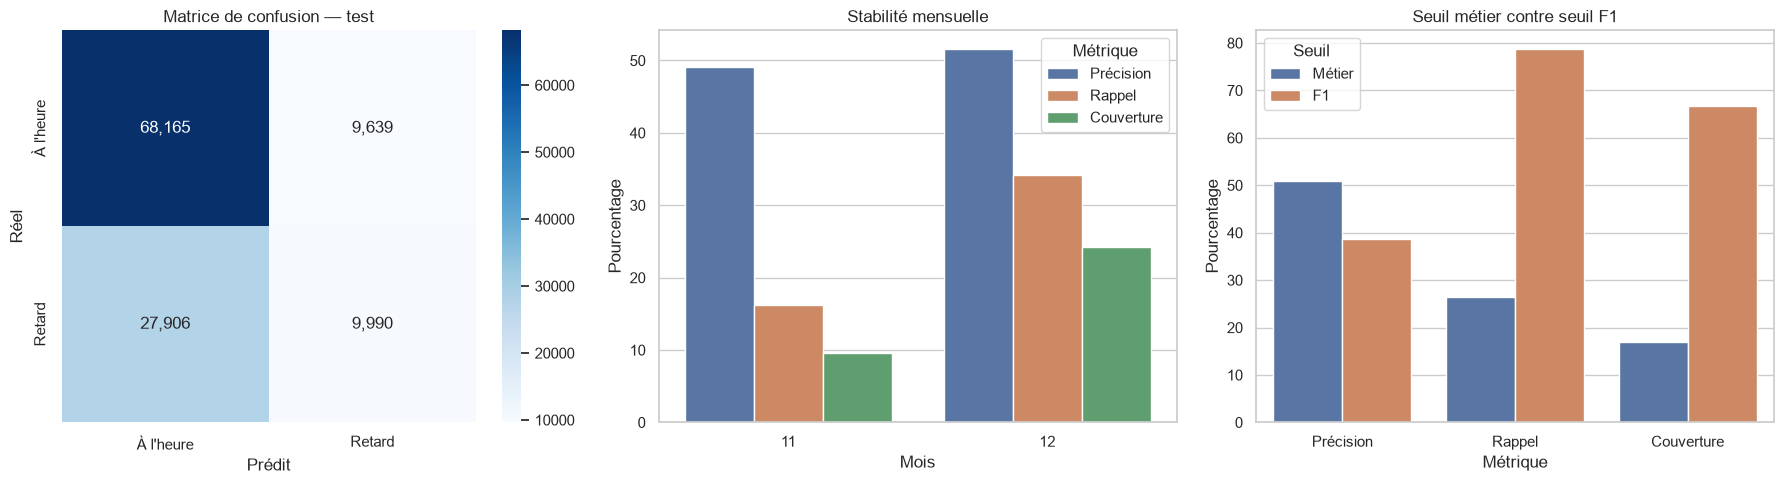

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

confusion = np.array(
    [
        [test_metrics["true_negative"], test_metrics["false_positive"]],
        [test_metrics["false_negative"], test_metrics["true_positive"]],
    ]
)
sns.heatmap(
    confusion,
    annot=True,
    fmt=",",
    cmap="Blues",
    xticklabels=["À l'heure", "Retard"],
    yticklabels=["À l'heure", "Retard"],
    ax=axes[0],
)
axes[0].set(title="Matrice de confusion — test", xlabel="Prédit", ylabel="Réel")

monthly_rows = []
for month, values in classification["test_by_month"].items():
    monthly_rows.extend(
        [
            {"Mois": int(month), "Métrique": "Précision", "Valeur": values["precision"] * 100},
            {"Mois": int(month), "Métrique": "Rappel", "Valeur": values["recall"] * 100},
            {"Mois": int(month), "Métrique": "Couverture", "Valeur": values["alert_coverage"] * 100},
        ]
    )
sns.barplot(data=pd.DataFrame(monthly_rows), x="Mois", y="Valeur", hue="Métrique", ax=axes[1])
axes[1].set(title="Stabilité mensuelle", ylabel="Pourcentage")

f1_test = classification["f1_threshold_comparison"]["test"]
threshold_comparison = pd.DataFrame(
    [
        {"Seuil": "Métier", "Précision": test_metrics["precision"] * 100, "Rappel": test_metrics["recall"] * 100, "Couverture": test_metrics["alert_coverage"] * 100},
        {"Seuil": "F1", "Précision": f1_test["precision"] * 100, "Rappel": f1_test["recall"] * 100, "Couverture": f1_test["alert_coverage"] * 100},
    ]
).melt(id_vars="Seuil", var_name="Métrique", value_name="Valeur")
sns.barplot(data=threshold_comparison, x="Métrique", y="Valeur", hue="Seuil", ax=axes[2])
axes[2].set(title="Seuil métier contre seuil F1", ylabel="Pourcentage")

plt.tight_layout()
plt.show()

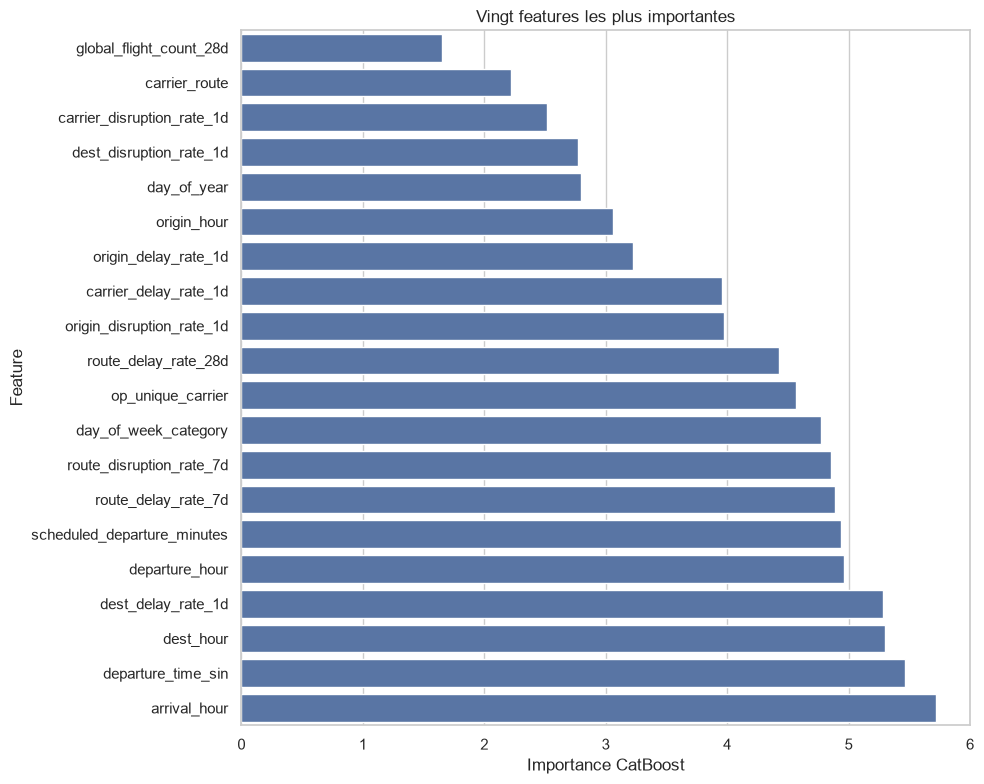

,feature,importance
0,arrival_hour,5.717505
1,departure_time_sin,5.464871
2,dest_hour,5.303389
3,dest_delay_rate_1d,5.283099
4,departure_hour,4.965179
5,scheduled_departure_minutes,4.935474
6,route_delay_rate_7d,4.884484
7,route_disruption_rate_7d,4.852220
8,day_of_week_category,4.772269
9,op_unique_carrier,4.568694


In [11]:
top_importance = feature_importance.head(20).sort_values("importance")
plt.figure(figsize=(10, 8))
sns.barplot(data=top_importance, x="importance", y="feature")
plt.title("Vingt features les plus importantes")
plt.xlabel("Importance CatBoost")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(feature_importance.head(20))

In [12]:
example_flight = json.loads(
    (PROJECT_ROOT / "examples/flight.json").read_text(encoding="utf-8")
)
prediction = predict_flight(bundle, example_flight)

prediction_table = pd.DataFrame(
    {
        "Indicateur": [
            "Probabilité diagnostique de retard",
            "Seuil du modèle",
            "Classe interne non publiable",
            "Prédiction publiable",
            "Contexte du planning",
        ],
        "Valeur": [
            f"{prediction['delay_probability']:.1%}",
            f"{prediction['classification_threshold']:.1%}",
            "Retard" if prediction["diagnostic_is_delayed_prediction"] else "À l'heure",
            "Oui" if prediction["prediction_publishable"] else "Non",
            prediction["schedule_context_source"],
        ],
    }
)
display(prediction_table)

if not prediction["prediction_publishable"]:
    display(Markdown("**Aucune alerte publiable. Raisons :**"))
    for blocker in prediction["publication_blockers"]:
        display(Markdown(f"- {blocker}"))

,Indicateur,Valeur
0,Probabilité diagnostique de retard,28.4%
1,Seuil du modèle,44.8%
2,Classe interne non publiable,À l'heure
3,Prédiction publiable,Non
4,Contexte du planning,typical_schedule_profile


**Aucune alerte publiable. Raisons :**

- Aucun seuil ne respecte toutes les contraintes sur la validation.

- Les contraintes métier ne sont pas respectées pour chaque mois de test.

- Les six volumes du planning journalier exact ne sont pas fournis.

# Étape 4 — Visualisation et prédiction avec Streamlit

L'interface finale se trouve dans `streamlit_app.py`. Elle contient quatre pages : vue d'ensemble, explorateur des vols, performances du modèle et formulaire de diagnostic.

Elle ne relance ni Spark ni l'entraînement à chaque interaction. Elle utilise l'échantillon versionné pour les graphiques et charge l'artefact v6 en cache pour la prédiction. Si l'artefact local manque ou est incompatible, le reste du dashboard continue de fonctionner.

In [13]:
streamlit_command = "uv run streamlit run streamlit_app.py"
display(Markdown("### Lancer l'interface"))
print(streamlit_command)

streamlit_pages = pd.DataFrame(
    {
        "Page": [
            "Vue d'ensemble",
            "Explorer les vols",
            "Performance du modèle",
            "Diagnostic d'un vol",
        ],
        "Contenu": [
            "Indicateurs Spark et résultat ML",
            "Filtres, graphiques et table des 10 000 vols",
            "Gate métier, confusion, stabilité et importance",
            "Formulaire pré-départ et diagnostic protégé",
        ],
    }
)
display(streamlit_pages)

### Lancer l'interface

uv run streamlit run streamlit_app.py


,Page,Contenu
0,Vue d'ensemble,Indicateurs Spark et résultat ML
1,Explorer les vols,"Filtres, graphiques et table des 10 000 vols"
2,Performance du modèle,"Gate métier, confusion, stabilité et importance"
3,Diagnostic d'un vol,Formulaire pré-départ et diagnostic protégé


In [14]:
test_precision = test_metrics["precision"]
test_recall = test_metrics["recall"]
test_coverage = test_metrics["alert_coverage"]
publication_status = (
    "Le contrat métier complet est respecté."
    if business_gate["passed"]
    else "Le contrat métier complet n'est pas respecté : le modèle reste expérimental."
)

display(
    Markdown(
        f"""## Conclusion

Le run chargé obtient **{test_precision:.1%} de précision**, **{test_recall:.1%} de rappel** et signale **{test_coverage:.1%} des vols** sur son test. {publication_status} Streamlit expose ce statut au lieu de transformer le diagnostic en promesse certaine."""
    )
)

## Conclusion

Le run chargé obtient **50.9% de précision**, **26.4% de rappel** et signale **17.0% des vols** sur son test. Le contrat métier complet n'est pas respecté : le modèle reste expérimental. Streamlit expose ce statut au lieu de transformer le diagnostic en promesse certaine.